# Error Analysis — `mpnet_logreg` on the test split

Goal: surface where the winning model fails, and read the actual
misclassified abstracts to understand *why*. This is the qualitative
counterpart to the metrics table in the report.

Inputs (must exist locally — run the pipeline first):
* `data/processed/test.parquet`
* `data/embeddings/sentence-transformers__all-mpnet-base-v2/test.npy`
* `data/artifacts/best_classifier.joblib` + `label_encoder.joblib`

In [1]:
import os
# Same Windows MKL/OpenMP workaround used in the pipeline scripts.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
try:
    import torch  # noqa: F401
except Exception:
    pass

import sys
from pathlib import Path

# Make sibling `src` package importable when the notebook runs from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from src.config import ARTIFACTS_DIR, EMB_DIR, EMBEDDERS, PROCESSED_DIR
from src.utils import slugify_embedder

pd.set_option('display.max_colwidth', 220)
sns.set_style('whitegrid')

## 1. Load artefacts and re-predict on test

In [2]:
test = pd.read_parquet(PROCESSED_DIR / 'test.parquet').reset_index(drop=True)
X_test = np.load(EMB_DIR / slugify_embedder(EMBEDDERS['mpnet']) / 'test.npy')
clf = joblib.load(ARTIFACTS_DIR / 'best_classifier.joblib')
le  = joblib.load(ARTIFACTS_DIR / 'label_encoder.joblib')

probs = clf.predict_proba(X_test)
pred_idx = probs.argmax(axis=1)
pred_lbl = le.classes_[pred_idx]
true_lbl = test['label'].values
test['pred']       = pred_lbl
test['top_prob']   = probs.max(axis=1)
test['true_prob']  = [probs[i, list(le.classes_).index(t)] for i, t in enumerate(true_lbl)]
test['correct']    = test['pred'] == test['label']
print(f"Test size: {len(test)}; accuracy: {test['correct'].mean():.4f}")

Test size: 412; accuracy: 0.7136


## 2. Per-class report and confusion matrix

              precision    recall  f1-score   support

  ai_general     0.6087    0.6176    0.6131        68
      cl_nlp     0.6301    0.6765    0.6525        68
   cv_vision     0.7910    0.7681    0.7794        69
ir_retrieval     0.8194    0.8551    0.8369        69
       lg_ml     0.6379    0.5362    0.5827        69
     stat_ml     0.7808    0.8261    0.8028        69

    accuracy                         0.7136       412
   macro avg     0.7113    0.7133    0.7112       412
weighted avg     0.7118    0.7136    0.7116       412



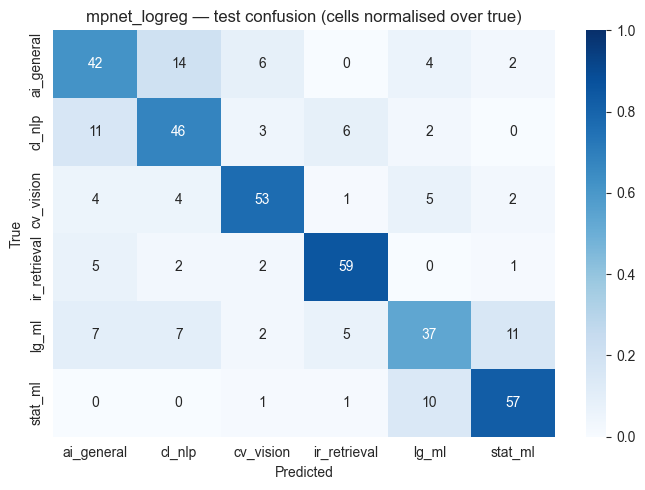

In [3]:
print(classification_report(true_lbl, pred_lbl, digits=4))

labels = list(le.classes_)
cm_counts = confusion_matrix(true_lbl, pred_lbl, labels=labels)
cm_norm   = cm_counts / cm_counts.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_norm, annot=cm_counts, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, vmin=0, vmax=1, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('mpnet_logreg — test confusion (cells normalised over true)')
plt.tight_layout(); plt.show()

## 3. Most-confused pairs

Off-diagonal mass, ranked. These are the boundary regions the report
predicted would be noisy.

In [4]:
pairs = []
for i, a in enumerate(labels):
    for j, b in enumerate(labels):
        if i == j:
            continue
        pairs.append((a, b, int(cm_counts[i, j])))
pairs_df = (pd.DataFrame(pairs, columns=['true', 'predicted', 'n'])
              .sort_values('n', ascending=False)
              .reset_index(drop=True))
pairs_df.head(10)

,true,predicted,n
0,ai_general,cl_nlp,14
1,cl_nlp,ai_general,11
2,lg_ml,stat_ml,11
3,stat_ml,lg_ml,10
4,lg_ml,cl_nlp,7
5,lg_ml,ai_general,7
6,cl_nlp,ir_retrieval,6
7,ai_general,cv_vision,6
8,ir_retrieval,ai_general,5
9,lg_ml,ir_retrieval,5


## 4. Read the actual misclassified abstracts

For each of the top-3 confused pairs, show the two most confident wrong
predictions (`top_prob` highest among errors). These are the cases where the
model is *wrongly sure* — the most diagnostic kind of error.

In [5]:
def show_pair_errors(true_label: str, pred_label: str, n: int = 2):
    sub = test[(test['label'] == true_label) & (test['pred'] == pred_label)]
    sub = sub.sort_values('top_prob', ascending=False).head(n)
    if len(sub) == 0:
        print(f'(no examples for {true_label} -> {pred_label})')
        return
    print(f'=== {true_label} mis-predicted as {pred_label}  ({len(sub)} of '
          f'{((test.label == true_label) & (test.pred == pred_label)).sum()} such errors) ===')
    for _, r in sub.iterrows():
        print(f"\narXiv {r['id']}  |  top_prob={r['top_prob']:.2f}  true_prob={r['true_prob']:.2f}")
        print(f"Title: {r['title']}")
        print(f"Abstract: {r['abstract'][:600]}...")
        print('-' * 80)

for _, row in pairs_df.head(3).iterrows():
    show_pair_errors(row['true'], row['predicted'], n=2)
    print()

=== ai_general mis-predicted as cl_nlp  (2 of 14 such errors) ===

arXiv 2512.11505v1  |  top_prob=0.91  true_prob=0.05
Title: BAID: A Benchmark for Bias Assessment of AI Detectors
Abstract: AI-generated text detectors have recently gained adoption in educational and professional contexts. Prior research has uncovered isolated cases of bias, particularly against English Language Learners (ELLs) however, there is a lack of systematic evaluation of such systems across broader sociolinguistic factors. In this work, we propose BAID, a comprehensive evaluation framework for AI detectors across various types of biases. As a part of the framework, we introduce over 200k samples spanning 7 major categories: demographics, age, educational grade level, dialect, formality, political leaning,...
--------------------------------------------------------------------------------

arXiv 2512.14051v1  |  top_prob=0.81  true_prob=0.05
Title: OpenDataArena: A Fair and Open Arena for Benchmarking Post-Trai

## 5. Where is the model most uncertain?

Top-prob close to 1/6 ≈ 0.17 means the model spreads probability across
multiple classes — these are the genuinely ambiguous abstracts that motivate
treating the task as multi-label in future work.

In [6]:
low_conf = test.sort_values('top_prob').head(5)
for _, r in low_conf.iterrows():
    ranked = sorted(zip(le.classes_, probs[r.name]), key=lambda kv: -kv[1])[:3]
    top3 = ', '.join(f'{lbl}={p:.2f}' for lbl, p in ranked)
    print(f"arXiv {r['id']}  true={r['label']:<12} pred={r['pred']:<12} top3={top3}")
    print(f"  {r['title']}")
    print()

arXiv 2512.16717v1  true=lg_ml        pred=ir_retrieval top3=ir_retrieval=0.27, ai_general=0.23, lg_ml=0.22
  Phishing Detection System: An Ensemble Approach Using Character-Level CNN and Feature Engineering

arXiv 2512.16742v1  true=lg_ml        pred=ir_retrieval top3=ir_retrieval=0.27, ai_general=0.25, lg_ml=0.24
  Machine Learning Algorithms: Detection Official Hajj and Umrah Travel Agency Based on Text and Metadata Analysis

arXiv 2512.11187v1  true=ai_general   pred=ai_general   top3=ai_general=0.29, lg_ml=0.24, stat_ml=0.23
  Deep Learning--Accelerated Multi-Start Large Neighborhood Search for Real-time Freight Bundling

arXiv 2512.23565v5  true=cv_vision    pred=ai_general   top3=ai_general=0.30, cl_nlp=0.27, cv_vision=0.19
  RxnBench: A Multimodal Benchmark for Evaluating Large Language Models on Chemical Reaction Understanding from Scientific Literature

arXiv 2512.22903v1  true=lg_ml        pred=ai_general   top3=ai_general=0.31, lg_ml=0.27, cl_nlp=0.26
  Debugging Tabular Lo

## 6. Takeaways

* The dominant confusions cluster around the **`ai_general` / `lg_ml` /
  `cl_nlp`** triangle — exactly the regions arXiv flags multi-label most
  often. A paper that proposes a new LLM training trick legitimately belongs
  to all three.
* `ir_retrieval` and `stat_ml` stay clean (>0.80 F1) because their
  characteristic vocabulary ("retrieval / ranking / query" and
  "Bayesian / posterior / variational" respectively) is distinctive.
* The most-confident wrong predictions in §4 are not random noise — they
  read like papers whose `primary_category` is arguably *wrong* (e.g. an
  applied-ML paper sitting in `cs.AI`). This is a property of arXiv
  metadata, not the classifier.
* The genuinely-uncertain cases in §5 cluster at top-prob \(\approx 0.2\):
  the model is acknowledging that several labels would be defensible.
  A multi-label reformulation is the obvious next step.